# COIL-100 layer-wise pose geometry analysis with DINOv2

This notebook extends the original COIL-100 pose-manifold experiment by asking a more specific question:

> At which DINOv2 layers is physical object pose best represented?

Instead of using only the final `[CLS]` embedding, the notebook extracts hidden states from every DINOv2 layer and repeats the within-object pose-distance analysis layer by layer.

The main outputs are:

1. layer-wise direct angular distance alignment with circular pose distance;
2. layer-wise kNN geodesic distance alignment with circular pose distance;
3. comparison between `[CLS]` pooling and mean patch-token pooling;
4. object-by-layer heatmaps showing which objects preserve pose geometry well;
5. example PCA pose loops for early, middle, and late layers.

The point is not merely to get a higher number, because numbers without interpretation are just spreadsheet confetti. The point is to see whether pose is strongest in early visual features, middle geometric features, or late semantic features.

## Setup

Run the install cell only if your environment is missing packages. In VSCode on Windows, select the same environment you used for the original COIL-100 notebook.

In [1]:

# Optional dependency install. Uncomment in a fresh environment.
# %pip install -q numpy pandas pillow matplotlib scikit-learn scipy torch torchvision transformers tqdm plotly


In [2]:

from __future__ import annotations

import math
import os
import re
import time
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, dijkstra
from scipy.stats import kendalltau, pearsonr, spearmanr
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

try:
    import torch
except ImportError as exc:
    raise ImportError("Install torch before running this notebook: pip install torch torchvision") from exc

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

# Your existing project folder. Change only if you moved the folder.
PROJECT_DIR = Path(r"D:\pyprojects\m4r\coil100_pose_manifold")

# Fallback for running this notebook from inside the project folder or from a copied repo.
if not PROJECT_DIR.exists():
    local_candidate = Path("coil100_pose_manifold")
    if local_candidate.exists():
        PROJECT_DIR = local_candidate
    else:
        PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
OUT_DIR = PROJECT_DIR / "outputs"
PLOT_DIR = OUT_DIR / "plots"
LAYERWISE_DIR = OUT_DIR / "layerwise"
LAYERWISE_PLOT_DIR = PLOT_DIR / "layerwise"

for d in [DATA_DIR, OUT_DIR, PLOT_DIR, LAYERWISE_DIR, LAYERWISE_PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "facebook/dinov2-base"
MODEL_TAG = MODEL_NAME.split("/")[-1].replace("-", "_")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64 if DEVICE == "cuda" else 16

# Keep all objects for the actual experiment. Set to a small number, such as 10,
# only when debugging the notebook.
MAX_OBJECTS = None
MAX_IMAGES_PER_OBJECT = None

# Layer-wise analysis settings.
K_MAX = 24
POOLING_MODES = ["cls", "mean_patch"]  # use ["cls"] if disk space is tight
N_PERMUTATIONS_FOR_BEST_LAYER = 100      # set to 0 to skip the slower validation cell

METADATA_CANDIDATES = [
    OUT_DIR / "coil100_metadata_for_embeddings.csv",
    OUT_DIR / "coil100_index_selected.csv",
    OUT_DIR / "coil100_index_all.csv",
]

print("Device:", DEVICE)
print("Batch size:", BATCH_SIZE)
print("Project directory:", PROJECT_DIR.resolve())
print("Layer-wise output directory:", LAYERWISE_DIR.resolve())


Device: cuda
Batch size: 64
Project directory: D:\pyprojects\m4r\coil100_pose_manifold
Layer-wise output directory: D:\pyprojects\m4r\coil100_pose_manifold\outputs\layerwise


d:\pyprojects\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load or rebuild COIL-100 metadata

This cell first tries to reuse the metadata CSV from your previous notebook. If that file is missing, it rebuilds the image index from the extracted COIL-100 images.

In [3]:

def build_coil100_index(image_root: Path) -> pd.DataFrame:
    pattern = re.compile(r"obj(?P<object_id>\d+)__(?P<angle>\d+)\.png$", re.IGNORECASE)
    rows = []
    for path in sorted(image_root.rglob("obj*__*.png")):
        m = pattern.search(path.name)
        if not m:
            continue
        rows.append({
            "object_id": int(m.group("object_id")),
            "angle": int(m.group("angle")),
            "image_path": str(path),
        })
    if not rows:
        raise FileNotFoundError(
            f"No COIL-100 images found under {image_root}. "
            "Run the original notebook first or extract coil-100.zip into the data folder."
        )
    return pd.DataFrame(rows).sort_values(["object_id", "angle"]).reset_index(drop=True)


def resolve_image_path(path_value: str | Path) -> Path:
    '''Resolve image paths saved by the original notebook, even if they were relative.'''
    p = Path(str(path_value))
    if p.exists():
        return p

    # If the original CSV used a path relative to the project directory.
    candidate = PROJECT_DIR / p
    if candidate.exists():
        return candidate

    # If the saved path contains a data/... suffix, rebuild it under PROJECT_DIR.
    parts = list(p.parts)
    if "data" in parts:
        i = parts.index("data")
        candidate = PROJECT_DIR / Path(*parts[i:])
        if candidate.exists():
            return candidate

    return p


def apply_debug_subsampling(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if MAX_OBJECTS is not None:
        keep = sorted(out["object_id"].unique())[: int(MAX_OBJECTS)]
        out = out[out["object_id"].isin(keep)].copy()
    if MAX_IMAGES_PER_OBJECT is not None:
        out = (
            out.groupby("object_id", group_keys=False)
            .apply(lambda g: g.sort_values("angle").head(int(MAX_IMAGES_PER_OBJECT)))
            .reset_index(drop=True)
        )
    return out.sort_values(["object_id", "angle"]).reset_index(drop=True)


def load_or_build_metadata() -> pd.DataFrame:
    for candidate in METADATA_CANDIDATES:
        if candidate.exists():
            print(f"Loading metadata: {candidate}")
            meta = pd.read_csv(candidate)
            break
    else:
        # Try common extraction directories used by the previous notebook.
        possible_roots = [
            DATA_DIR / "coil-100-extracted",
            DATA_DIR / "coil-100",
            DATA_DIR,
        ]
        for root in possible_roots:
            try:
                meta = build_coil100_index(root)
                print(f"Built metadata from images under: {root}")
                break
            except FileNotFoundError:
                meta = None
        if meta is None:
            raise FileNotFoundError("Could not find metadata CSV or extracted COIL-100 images.")

    required = {"object_id", "angle", "image_path"}
    missing = required - set(meta.columns)
    if missing:
        raise ValueError(f"Metadata is missing columns: {sorted(missing)}")

    meta = meta.copy()
    meta["object_id"] = meta["object_id"].astype(int)
    meta["angle"] = meta["angle"].astype(int)
    meta["image_path"] = meta["image_path"].map(lambda p: str(resolve_image_path(p)))
    meta = apply_debug_subsampling(meta)

    missing_paths = [p for p in meta["image_path"].head(20) if not Path(p).exists()]
    if missing_paths:
        print("Warning: some image paths do not exist. First few missing paths:")
        for p in missing_paths[:5]:
            print("  ", p)
        print("If this happens on Windows, check PROJECT_DIR and rerun this cell.")

    out_path = LAYERWISE_DIR / "coil100_layerwise_metadata.csv"
    meta.to_csv(out_path, index=False)
    print(f"Saved layer-wise metadata copy: {out_path}")
    print("Images:", len(meta))
    print("Objects:", meta["object_id"].nunique())
    print("Angles per first objects:")
    display(meta.groupby("object_id")["angle"].nunique().head())
    return meta

metadata = load_or_build_metadata()
metadata.head()


Loading metadata: D:\pyprojects\m4r\coil100_pose_manifold\outputs\coil100_metadata_for_embeddings.csv
Saved layer-wise metadata copy: D:\pyprojects\m4r\coil100_pose_manifold\outputs\layerwise\coil100_layerwise_metadata.csv
Images: 7200
Objects: 100
Angles per first objects:


object_id
1    72
2    72
3    72
4    72
5    72
Name: angle, dtype: int64

,image_path,object_id,angle,angle_label,embedding_model,embedding_type
0,coil100_pose_manifold\data\coil-100-extracted\...,1,0,0,facebook/dinov2-base,last_hidden_state_cls_l2_normalized
1,coil100_pose_manifold\data\coil-100-extracted\...,1,5,1,facebook/dinov2-base,last_hidden_state_cls_l2_normalized
2,coil100_pose_manifold\data\coil-100-extracted\...,1,10,2,facebook/dinov2-base,last_hidden_state_cls_l2_normalized
3,coil100_pose_manifold\data\coil-100-extracted\...,1,15,3,facebook/dinov2-base,last_hidden_state_cls_l2_normalized
4,coil100_pose_manifold\data\coil-100-extracted\...,1,20,4,facebook/dinov2-base,last_hidden_state_cls_l2_normalized


## Distance and manifold helpers

Ground-truth pose distance is circular, so `0°` and `355°` are treated as close, not as opposite ends of a very stupid ruler.

In [4]:

def l2_normalize(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    X = np.asarray(X)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, eps)


def upper_values(D: np.ndarray) -> np.ndarray:
    idx = np.triu_indices(D.shape[0], k=1)
    return D[idx]


def angular_distance_matrix(X: np.ndarray) -> np.ndarray:
    Xn = l2_normalize(np.asarray(X, dtype=np.float64))
    sims = np.clip(Xn @ Xn.T, -1.0, 1.0)
    return np.arccos(sims) / np.pi


def circular_angle_distance_matrix(angles: np.ndarray, period: float = 360.0) -> np.ndarray:
    a = np.asarray(angles, dtype=float).reshape(-1, 1)
    diff = np.abs(a - a.T)
    return np.minimum(diff, period - diff) / (period / 2.0)


def corr_stats(x: np.ndarray, y: np.ndarray) -> dict[str, float]:
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return {
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "spearman_rho": np.nan,
            "spearman_p": np.nan,
            "kendall_tau": np.nan,
            "kendall_p": np.nan,
            "n_pairs": int(len(x)),
        }
    pr = pearsonr(x, y)
    sr = spearmanr(x, y)
    kt = kendalltau(x, y)
    return {
        "pearson_r": float(pr.statistic),
        "pearson_p": float(pr.pvalue),
        "spearman_rho": float(sr.statistic),
        "spearman_p": float(sr.pvalue),
        "kendall_tau": float(kt.statistic),
        "kendall_p": float(kt.pvalue),
        "n_pairs": int(len(x)),
    }


def symmetric_knn_graph_from_distance(D: np.ndarray, k: int) -> csr_matrix:
    n = D.shape[0]
    if not 1 <= k < n:
        raise ValueError(f"k must be in [1, n-1]; got k={k}, n={n}")
    indices = np.argsort(D, axis=1)[:, 1:k + 1]
    rows = np.repeat(np.arange(n), k)
    cols = indices.reshape(-1)
    vals = D[rows, cols]
    G = csr_matrix((vals, (rows, cols)), shape=(n, n))
    return G.maximum(G.T)


def connected_geodesic_from_distance(D: np.ndarray, k_max: int = 24) -> tuple[np.ndarray, int, int]:
    n = D.shape[0]
    upper_k = min(k_max, n - 1)
    last_components = None
    for k in range(1, upper_k + 1):
        G = symmetric_knn_graph_from_distance(D, k)
        n_components, _ = connected_components(G, directed=False)
        last_components = int(n_components)
        if n_components == 1:
            geo = dijkstra(G, directed=False, return_predecessors=False)
            return geo, k, int(n_components)

    # Fall back to the densest tried graph. Disconnected results will contain inf.
    G = symmetric_knn_graph_from_distance(D, upper_k)
    geo = dijkstra(G, directed=False, return_predecessors=False)
    return geo, upper_k, int(last_components or -1)


def analyze_single_object_fast(X_obj: np.ndarray, angles: np.ndarray, object_id: int, k_max: int = 24) -> dict:
    D_gt = circular_angle_distance_matrix(angles)
    gt_upper = upper_values(D_gt)

    D_emb = angular_distance_matrix(X_obj)
    emb_upper = upper_values(D_emb)
    direct = corr_stats(gt_upper, emb_upper)

    D_geo, k_used, n_components = connected_geodesic_from_distance(D_emb, k_max=k_max)
    geo_upper = upper_values(D_geo)
    geodesic = corr_stats(gt_upper, geo_upper)

    return {
        "object_id": int(object_id),
        "n_images": int(len(angles)),
        "direct_angular_spearman": direct["spearman_rho"],
        "direct_angular_pearson": direct["pearson_r"],
        "direct_angular_kendall": direct["kendall_tau"],
        "geodesic_angular_spearman": geodesic["spearman_rho"],
        "geodesic_angular_pearson": geodesic["pearson_r"],
        "geodesic_angular_kendall": geodesic["kendall_tau"],
        "geodesic_knn_k": int(k_used),
        "geodesic_connected_components": int(n_components),
        "n_pairs": direct["n_pairs"],
    }


def run_object_level_analysis_fast(X: np.ndarray, meta: pd.DataFrame, k_max: int = 24) -> pd.DataFrame:
    if len(X) != len(meta):
        raise ValueError(f"Embedding and metadata lengths differ: {len(X)} vs {len(meta)}")

    rows = []
    meta_work = meta.reset_index(drop=True).copy()
    meta_work["_row"] = np.arange(len(meta_work))

    for object_id, group in meta_work.groupby("object_id"):
        group = group.sort_values("angle")
        idx = group["_row"].to_numpy()
        angles = group["angle"].to_numpy()
        if len(np.unique(angles)) < 6:
            continue
        rows.append(analyze_single_object_fast(X[idx], angles, int(object_id), k_max=k_max))

    return pd.DataFrame(rows).sort_values("object_id").reset_index(drop=True)


## Extract and cache layer-wise DINOv2 embeddings

This is the expensive part. It runs DINOv2 once and saves one `.npz` file per pooling mode:

- `cls`: the `[CLS]` token at each hidden layer;
- `mean_patch`: the mean of all patch tokens at each hidden layer.

The cache is intentionally separate from your original final-layer embedding file, because we now need hidden states from every layer. Apparently the model will not go back in time and provide them retroactively. Rude, but predictable.

In [5]:

def load_rgb(path: str | Path) -> Image.Image:
    return Image.open(path).convert("RGB")


def layer_key(layer_idx: int) -> str:
    return f"layer_{layer_idx:02d}"


def npz_path_for_pooling(pooling: str) -> Path:
    return LAYERWISE_DIR / f"{MODEL_TAG}_layerwise_{pooling}.npz"


def cached_layerwise_embeddings_available(pooling_modes: list[str]) -> bool:
    return all(npz_path_for_pooling(mode).exists() for mode in pooling_modes)


def extract_layerwise_dinov2_embeddings(
    df: pd.DataFrame,
    model_name: str,
    pooling_modes: list[str],
    batch_size: int,
    device: str,
    force_recompute: bool = False,
) -> dict[str, dict[int, np.ndarray]]:
    '''Return {pooling_mode: {layer_idx: embedding_array}} and cache to disk.'''
    if (not force_recompute) and cached_layerwise_embeddings_available(pooling_modes):
        loaded = {}
        for mode in pooling_modes:
            path = npz_path_for_pooling(mode)
            with np.load(path) as data:
                layer_dict = {int(k.split("_")[1]): data[k] for k in data.files if k.startswith("layer_")}
            loaded[mode] = dict(sorted(layer_dict.items()))
            print(f"Loaded cached {mode} embeddings from {path}")
        return loaded

    try:
        from transformers import AutoImageProcessor, AutoModel
    except ImportError as exc:
        raise ImportError("Install transformers first: pip install transformers") from exc

    print(f"Loading {model_name} on {device}")
    processor = AutoImageProcessor.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.to(device)
    model.eval()

    collectors: dict[str, dict[int, list[np.ndarray]]] = {mode: {} for mode in pooling_modes}
    paths = df["image_path"].tolist()

    with torch.inference_mode():
        for start in tqdm(range(0, len(paths), batch_size), desc="Extracting hidden states"):
            batch_paths = paths[start:start + batch_size]
            images = [load_rgb(p) for p in batch_paths]
            inputs = processor(images=images, return_tensors="pt")
            inputs = {k: v.to(device) for k, v in inputs.items()}

            outputs = model(**inputs, output_hidden_states=True, return_dict=True)
            hidden_states = outputs.hidden_states

            for layer_idx, h in enumerate(hidden_states):
                # h shape: [batch, tokens, dim]. Token 0 is CLS for ViT-style models.
                if "cls" in pooling_modes:
                    arr = h[:, 0, :].detach().cpu().numpy().astype(np.float32)
                    collectors["cls"].setdefault(layer_idx, []).append(arr)

                if "mean_patch" in pooling_modes:
                    arr = h[:, 1:, :].mean(dim=1).detach().cpu().numpy().astype(np.float32)
                    collectors["mean_patch"].setdefault(layer_idx, []).append(arr)

    result: dict[str, dict[int, np.ndarray]] = {}
    for mode in pooling_modes:
        layer_arrays = {}
        for layer_idx, chunks in collectors[mode].items():
            X = np.vstack(chunks).astype(np.float32)
            X = l2_normalize(X).astype(np.float32)
            layer_arrays[layer_idx] = X

        out_path = npz_path_for_pooling(mode)
        np.savez_compressed(out_path, **{layer_key(i): X for i, X in layer_arrays.items()})
        print(f"Saved {mode} layer-wise embeddings: {out_path}")
        result[mode] = layer_arrays

    return result


layerwise_embeddings = extract_layerwise_dinov2_embeddings(
    df=metadata,
    model_name=MODEL_NAME,
    pooling_modes=POOLING_MODES,
    batch_size=BATCH_SIZE,
    device=DEVICE,
    force_recompute=False,
)

for mode, layers in layerwise_embeddings.items():
    print(mode, "layers:", list(layers.keys()), "shape of first layer:", next(iter(layers.values())).shape)


Loaded cached cls embeddings from D:\pyprojects\m4r\coil100_pose_manifold\outputs\layerwise\dinov2_base_layerwise_cls.npz
Loaded cached mean_patch embeddings from D:\pyprojects\m4r\coil100_pose_manifold\outputs\layerwise\dinov2_base_layerwise_mean_patch.npz
cls layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] shape of first layer: (7200, 768)
mean_patch layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] shape of first layer: (7200, 768)


## Run pose-geometry analysis for every layer

For each layer and pooling mode, this cell computes object-wise correlations between circular pose distance and embedding distance.

The main comparison is:

- **direct angular distance**: global pairwise embedding distance;
- **kNN geodesic distance**: shortest path over a local neighborhood graph.

If geodesic distance consistently beats direct distance, the pose signal is probably arranged along a local manifold rather than as a simple global radial distance. Tiny victory for geometry; tragic inconvenience for simple baselines.

In [6]:
def summarize_metric(obj: pd.DataFrame, metric: str, pooling: str, layer_idx: int) -> dict | None:
    s = pd.to_numeric(obj[metric], errors="coerce").dropna()
    if s.empty:
        return None
    return {
        "pooling": pooling,
        "layer": int(layer_idx),
        "metric": metric,
        "n_objects": int(s.shape[0]),
        "mean": float(s.mean()),
        "std": float(s.std(ddof=1)) if len(s) > 1 else np.nan,
        "median": float(s.median()),
        "q25": float(s.quantile(0.25)),
        "q75": float(s.quantile(0.75)),
        "min": float(s.min()),
        "max": float(s.max()),
    }


def analyze_all_layers(
    layerwise: dict[str, dict[int, np.ndarray]],
    meta: pd.DataFrame,
    k_max: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    object_rows = []
    summary_rows = []

    metrics_to_summarize = [
        "direct_angular_spearman",
        "direct_angular_pearson",
        "geodesic_angular_spearman",
        "geodesic_angular_pearson",
        "geodesic_knn_k",
    ]

    for pooling, layers in layerwise.items():
        for layer_idx, X_layer in tqdm(list(layers.items()), desc=f"Analyzing {pooling}"):
            obj = run_object_level_analysis_fast(X_layer, meta, k_max=k_max)
            obj["pooling"] = pooling
            obj["layer"] = int(layer_idx)
            object_rows.append(obj)

            for metric in metrics_to_summarize:
                row = summarize_metric(obj, metric, pooling, int(layer_idx))
                if row is not None:
                    summary_rows.append(row)

    object_level = pd.concat(object_rows, ignore_index=True)
    summary = pd.DataFrame(summary_rows).sort_values(["pooling", "metric", "layer"]).reset_index(drop=True)
    return object_level, summary


object_layer_results, layer_summary = analyze_all_layers(layerwise_embeddings, metadata, k_max=K_MAX)

object_results_path = LAYERWISE_DIR / "layerwise_object_level_pose_alignment.csv"
summary_path = LAYERWISE_DIR / "layerwise_pose_alignment_summary.csv"
object_layer_results.to_csv(object_results_path, index=False)
layer_summary.to_csv(summary_path, index=False)

print(f"Saved object-level results: {object_results_path}")
print(f"Saved summary: {summary_path}")

layer_summary.head(12)

Analyzing mean_patch: 100%|██████████| 13/13 [00:07<00:00,  1.76it/s]

Saved object-level results: D:\pyprojects\m4r\coil100_pose_manifold\outputs\layerwise\layerwise_object_level_pose_alignment.csv
Saved summary: D:\pyprojects\m4r\coil100_pose_manifold\outputs\layerwise\layerwise_pose_alignment_summary.csv


,pooling,layer,metric,n_objects,mean,std,median,q25,q75,min,max
0,cls,1,direct_angular_pearson,100,0.235644,0.197142,0.196202,0.062357,0.376088,-0.020869,0.663430
1,cls,2,direct_angular_pearson,100,0.273909,0.215597,0.256184,0.076588,0.468756,-0.010672,0.691180
2,cls,3,direct_angular_pearson,100,0.285955,0.219402,0.260644,0.077445,0.481426,-0.009062,0.718865
3,cls,4,direct_angular_pearson,100,0.353990,0.247010,0.357231,0.104204,0.584945,-0.000131,0.775686
4,cls,5,direct_angular_pearson,100,0.355230,0.225388,0.365863,0.145720,0.575761,0.008042,0.737611
5,cls,6,direct_angular_pearson,100,0.336681,0.209983,0.321130,0.146961,0.525770,0.013280,0.712101
6,cls,7,direct_angular_pearson,100,0.395049,0.219347,0.391016,0.193393,0.598354,0.034004,0.783816
7,cls,8,direct_angular_pearson,100,0.374222,0.225066,0.358046,0.162919,0.588272,0.030262,0.758172
8,cls,9,direct_angular_pearson,100,0.432757,0.237553,0.461420,0.215013,0.651505,0.051941,0.791432
9,cls,10,direct_angular_pearson,100,0.432405,0.232977,0.460311,0.225290,0.623960,0.052916,0.858750


## Layer-wise summary plots

These plots answer the central question: which layers preserve pose geometry best?

Saved: D:\pyprojects\m4r\coil100_pose_manifold\outputs\plots\layerwise\layerwise_pose_spearman_cls.png


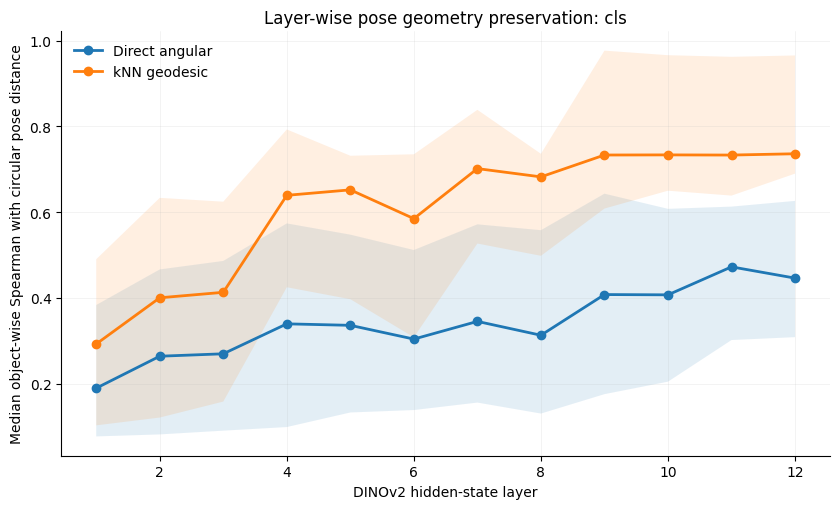

Saved: D:\pyprojects\m4r\coil100_pose_manifold\outputs\plots\layerwise\layerwise_pose_spearman_mean_patch.png


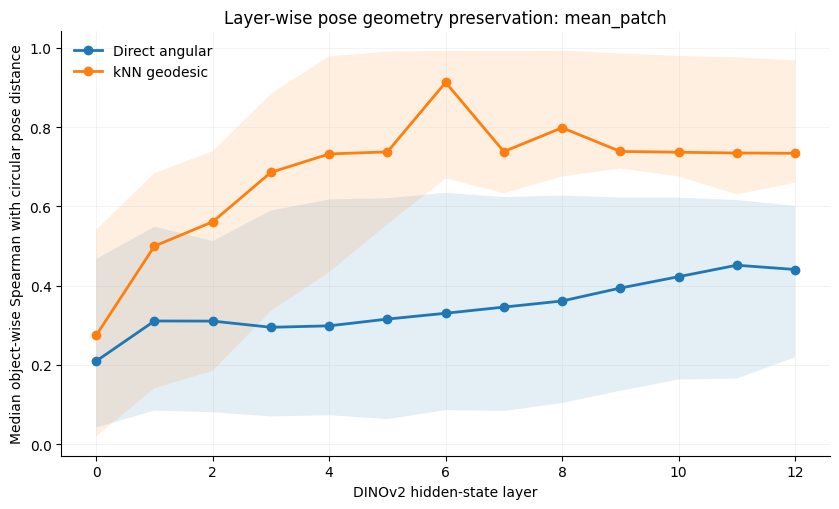

Saved: D:\pyprojects\m4r\coil100_pose_manifold\outputs\plots\layerwise\layerwise_connected_knn_k.png


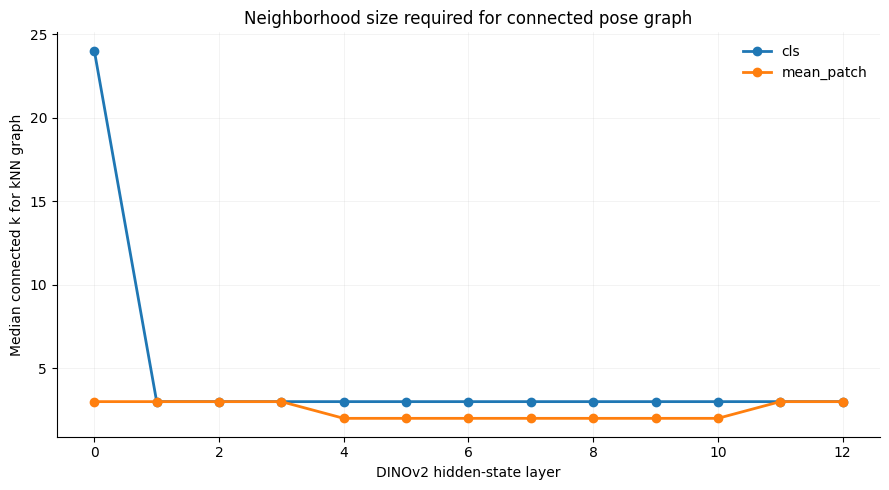

In [7]:
def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, linewidth=0.4, alpha=0.25)


def plot_layerwise_spearman_for_pooling(summary: pd.DataFrame, pooling: str) -> None:
    fig, ax = plt.subplots(figsize=(8.5, 5.2))

    plot_df = summary[
        summary["pooling"].eq(pooling)
        & summary["metric"].isin(["direct_angular_spearman", "geodesic_angular_spearman"])
    ].copy()

    label_map = {
        "direct_angular_spearman": "Direct angular",
        "geodesic_angular_spearman": "kNN geodesic",
    }

    for metric in ["direct_angular_spearman", "geodesic_angular_spearman"]:
        g = plot_df[plot_df["metric"].eq(metric)].sort_values("layer")
        if g.empty:
            continue
        ax.plot(g["layer"], g["median"], marker="o", linewidth=2, label=label_map[metric])
        ax.fill_between(g["layer"], g["q25"], g["q75"], alpha=0.12)

    ax.set_xlabel("DINOv2 hidden-state layer")
    ax.set_ylabel("Median object-wise Spearman with circular pose distance")
    ax.set_title(f"Layer-wise pose geometry preservation: {pooling}")
    ax.legend(frameon=False)
    clean_axes(ax)
    fig.tight_layout()
    out_path = LAYERWISE_PLOT_DIR / f"layerwise_pose_spearman_{pooling}.png"
    fig.savefig(out_path, dpi=220)
    print(f"Saved: {out_path}")
    plt.show()


def plot_layerwise_spearman_split(summary: pd.DataFrame, pooling_order: list[str] | None = None) -> None:
    if pooling_order is None:
        pooling_order = ["cls", "mean_patch"]
    for pooling in pooling_order:
        if pooling in set(summary["pooling"]):
            plot_layerwise_spearman_for_pooling(summary, pooling)


def plot_layerwise_geodesic_k(summary: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(9, 5))
    plot_df = summary[summary["metric"].eq("geodesic_knn_k")].copy()
    for pooling, g in plot_df.groupby("pooling"):
        g = g.sort_values("layer")
        ax.plot(g["layer"], g["median"], marker="o", linewidth=2, label=pooling)
    ax.set_xlabel("DINOv2 hidden-state layer")
    ax.set_ylabel("Median connected k for kNN graph")
    ax.set_title("Neighborhood size required for connected pose graph")
    ax.legend(frameon=False)
    clean_axes(ax)
    fig.tight_layout()
    out_path = LAYERWISE_PLOT_DIR / "layerwise_connected_knn_k.png"
    fig.savefig(out_path, dpi=220)
    print(f"Saved: {out_path}")
    plt.show()


plot_layerwise_spearman_split(layer_summary, pooling_order=["cls", "mean_patch"])
plot_layerwise_geodesic_k(layer_summary)

## Best layers and object-wise variability

A single median can hide the fun part: some objects may have clean pose loops in early layers, while others survive into later layers. This cell identifies the best layer overall and the best layer per object.

In [8]:
def best_layer_table(summary: pd.DataFrame) -> pd.DataFrame:
    rows = []
    method_pairs = [
        ("direct_angular", "direct_angular_spearman", "direct_angular_pearson"),
        ("knn_geodesic", "geodesic_angular_spearman", "geodesic_angular_pearson"),
    ]

    for pooling in sorted(summary["pooling"].unique()):
        for method_name, spearman_metric, pearson_metric in method_pairs:
            sp = summary[(summary["pooling"].eq(pooling)) & (summary["metric"].eq(spearman_metric))].copy()
            pr = summary[(summary["pooling"].eq(pooling)) & (summary["metric"].eq(pearson_metric))].copy()
            if sp.empty:
                continue

            # Pick the best layer by median Spearman, then report both correlations at that layer.
            best_sp = sp.sort_values("median", ascending=False).iloc[0]
            best_layer = int(best_sp["layer"])
            pr_at_layer = pr[pr["layer"].eq(best_layer)]
            best_pr = pr_at_layer.iloc[0] if not pr_at_layer.empty else None

            rows.append({
                "pooling": pooling,
                "distance_method": method_name,
                "best_layer_by_spearman": best_layer,
                "median_spearman": float(best_sp["median"]),
                "spearman_q25": float(best_sp["q25"]),
                "spearman_q75": float(best_sp["q75"]),
                "median_pearson_at_same_layer": float(best_pr["median"]) if best_pr is not None else np.nan,
                "pearson_q25_at_same_layer": float(best_pr["q25"]) if best_pr is not None else np.nan,
                "pearson_q75_at_same_layer": float(best_pr["q75"]) if best_pr is not None else np.nan,
                "n_objects": int(best_sp["n_objects"]),
            })

    return pd.DataFrame(rows).sort_values(["pooling", "distance_method"]).reset_index(drop=True)


best_layers = best_layer_table(layer_summary)
best_layers.to_csv(LAYERWISE_DIR / "best_layer_summary.csv", index=False)
best_layers

,pooling,distance_method,best_layer_by_spearman,median_spearman,spearman_q25,spearman_q75,median_pearson_at_same_layer,pearson_q25_at_same_layer,pearson_q75_at_same_layer,n_objects
0,cls,direct_angular,11,0.472413,0.301712,0.612954,0.485597,0.321960,0.635854,100
1,cls,knn_geodesic,12,0.736222,0.689913,0.965542,0.666057,0.593524,0.963948,100
2,mean_patch,direct_angular,11,0.451323,0.165308,0.615763,0.479160,0.163200,0.632117,100
3,mean_patch,knn_geodesic,6,0.912580,0.670262,0.992537,0.909605,0.589303,0.992417,100


Saved: D:\pyprojects\m4r\coil100_pose_manifold\outputs\plots\layerwise\best_layer_distribution_cls_geodesic_angular_spearman.png


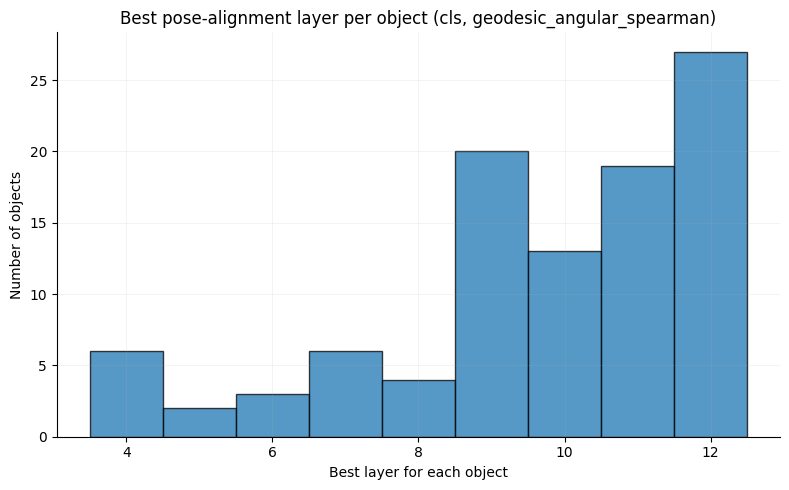

Saved: D:\pyprojects\m4r\coil100_pose_manifold\outputs\plots\layerwise\best_layer_distribution_mean_patch_geodesic_angular_spearman.png


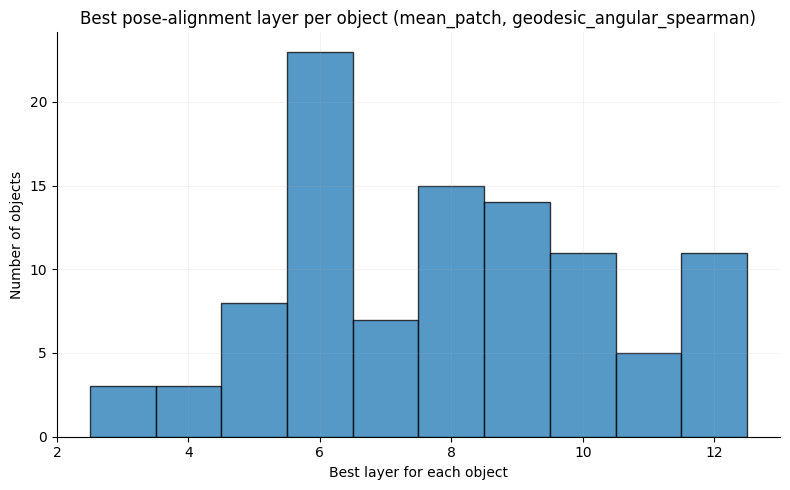

In [9]:

def plot_best_layer_distribution(object_results: pd.DataFrame, metric: str = "geodesic_angular_spearman") -> None:
    for pooling, g in object_results.groupby("pooling"):
        idx = g.groupby("object_id")[metric].idxmax()
        best = g.loc[idx, ["object_id", "layer", metric]].sort_values("object_id")
        best.to_csv(LAYERWISE_DIR / f"best_layer_per_object_{pooling}_{metric}.csv", index=False)

        fig, ax = plt.subplots(figsize=(8, 5))
        bins = np.arange(best["layer"].min() - 0.5, best["layer"].max() + 1.5, 1)
        ax.hist(best["layer"], bins=bins, edgecolor="black", alpha=0.75)
        ax.set_xlabel("Best layer for each object")
        ax.set_ylabel("Number of objects")
        ax.set_title(f"Best pose-alignment layer per object ({pooling}, {metric})")
        clean_axes(ax)
        fig.tight_layout()
        out_path = LAYERWISE_PLOT_DIR / f"best_layer_distribution_{pooling}_{metric}.png"
        fig.savefig(out_path, dpi=220)
        print(f"Saved: {out_path}")
        plt.show()


plot_best_layer_distribution(object_layer_results, metric="geodesic_angular_spearman")


## Object-by-layer heatmap

This heatmap shows whether the layer effect is consistent across objects or driven by a few convenient little overachievers.

Saved: D:\pyprojects\m4r\coil100_pose_manifold\outputs\plots\layerwise\object_layer_heatmap_cls_geodesic_angular_spearman.png


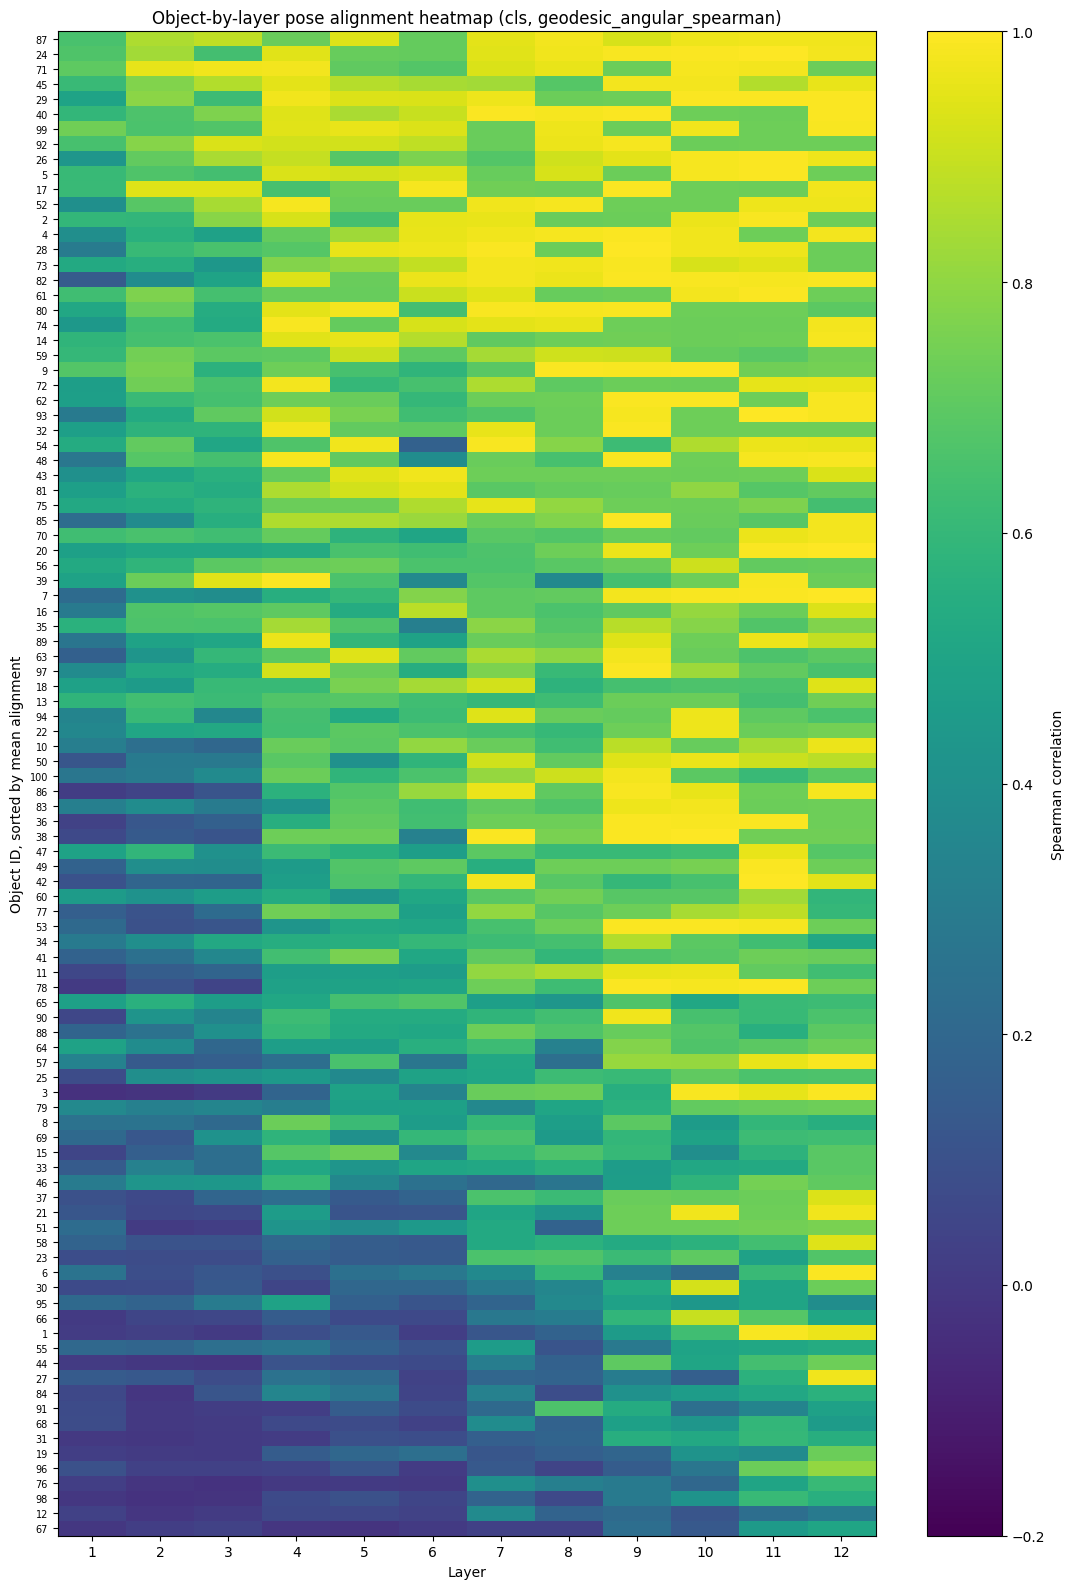

Saved: D:\pyprojects\m4r\coil100_pose_manifold\outputs\plots\layerwise\object_layer_heatmap_mean_patch_geodesic_angular_spearman.png


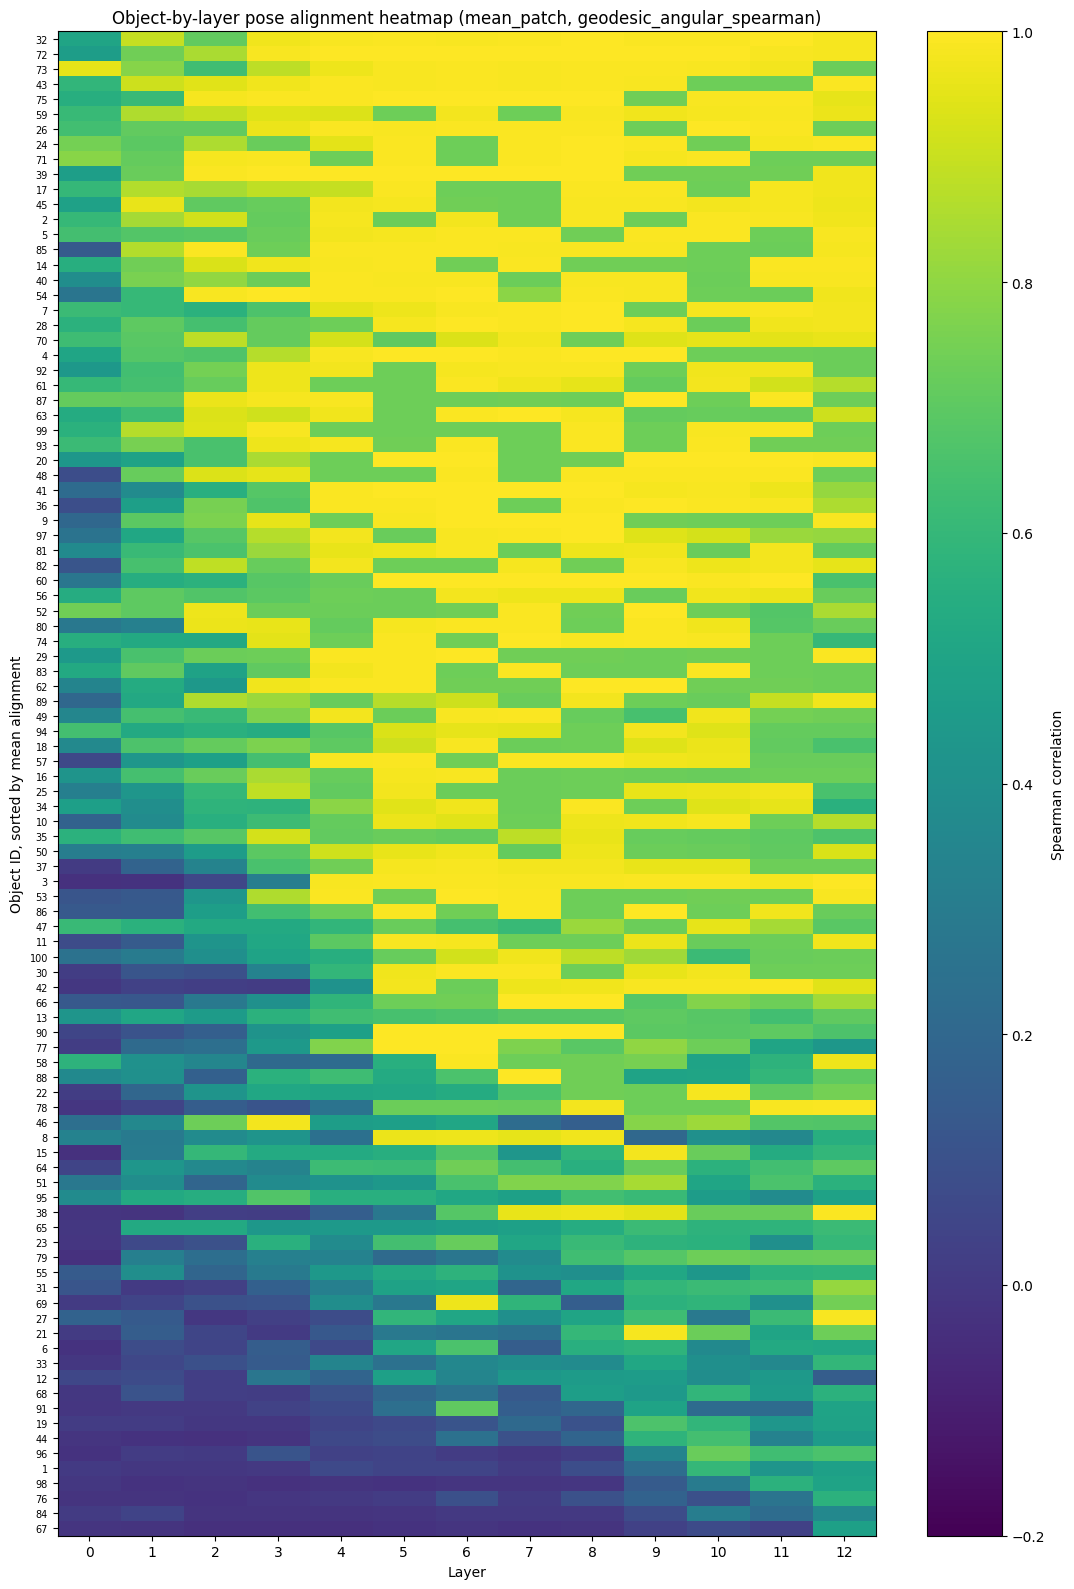

In [10]:

def plot_object_layer_heatmap(
    object_results: pd.DataFrame,
    pooling: str = "cls",
    metric: str = "geodesic_angular_spearman",
    max_objects: int | None = None,
) -> None:
    g = object_results[object_results["pooling"].eq(pooling)].copy()
    pivot = g.pivot_table(index="object_id", columns="layer", values=metric, aggfunc="mean")
    pivot["_mean"] = pivot.mean(axis=1)
    pivot = pivot.sort_values("_mean", ascending=False).drop(columns="_mean")
    if max_objects is not None:
        pivot = pivot.head(max_objects)

    fig_height = max(6, min(18, 0.13 * len(pivot) + 3))
    fig, ax = plt.subplots(figsize=(11, fig_height))
    im = ax.imshow(pivot.values, aspect="auto", interpolation="nearest", vmin=-0.2, vmax=1.0)
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([str(c) for c in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([str(i) for i in pivot.index], fontsize=7)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Object ID, sorted by mean alignment")
    ax.set_title(f"Object-by-layer pose alignment heatmap ({pooling}, {metric})")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Spearman correlation")
    fig.tight_layout()
    out_path = LAYERWISE_PLOT_DIR / f"object_layer_heatmap_{pooling}_{metric}.png"
    fig.savefig(out_path, dpi=220)
    print(f"Saved: {out_path}")
    plt.show()


for pooling in POOLING_MODES:
    plot_object_layer_heatmap(
        object_layer_results,
        pooling=pooling,
        metric="geodesic_angular_spearman",
        max_objects=None,
    )


## Example pose loops across early, middle, and late layers

This visually checks whether the layer-wise statistics correspond to actual loop-like structure. The notebook chooses a representative object near the median final-layer geodesic score, unless you override `EXAMPLE_OBJECT_ID`.

In [11]:

def choose_representative_object(object_results: pd.DataFrame, pooling: str = "cls") -> int:
    final_layer = int(object_results[object_results["pooling"].eq(pooling)]["layer"].max())
    g = object_results[(object_results["pooling"].eq(pooling)) & (object_results["layer"].eq(final_layer))].copy()
    med = g["geodesic_angular_spearman"].median()
    g["_delta"] = (g["geodesic_angular_spearman"] - med).abs()
    return int(g.sort_values("_delta").iloc[0]["object_id"])


EXAMPLE_OBJECT_ID = choose_representative_object(object_layer_results, pooling="cls")
print("Representative object:", EXAMPLE_OBJECT_ID)


Representative object: 53


Saved: D:\pyprojects\m4r\coil100_pose_manifold\outputs\plots\layerwise\object_032_cls_layer_01_pose_loop.png


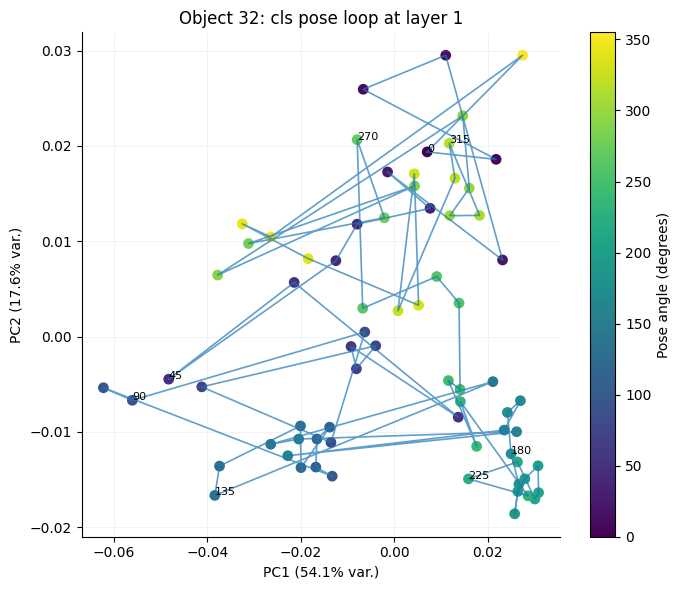

Saved: D:\pyprojects\m4r\coil100_pose_manifold\outputs\plots\layerwise\object_032_cls_layer_06_pose_loop.png


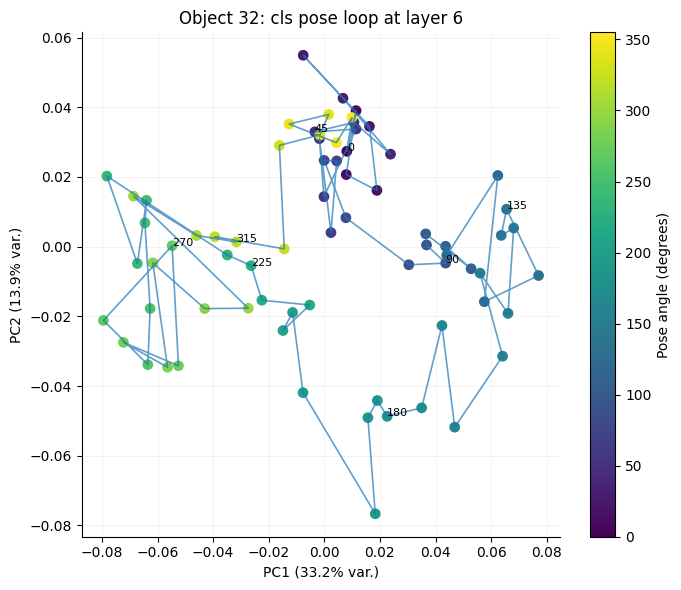

Saved: D:\pyprojects\m4r\coil100_pose_manifold\outputs\plots\layerwise\object_032_cls_layer_12_pose_loop.png


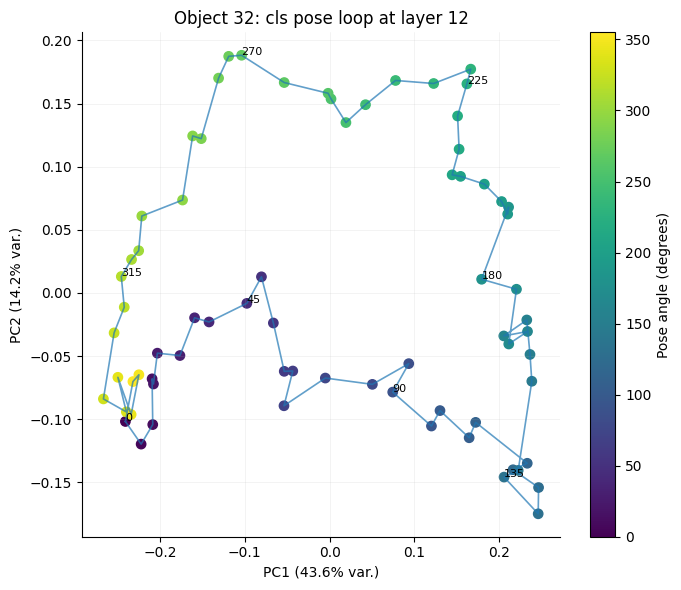

In [12]:

def object_indices_and_angles(meta: pd.DataFrame, object_id: int) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    meta_work = meta.reset_index(drop=True).copy()
    meta_work["_row"] = np.arange(len(meta_work))
    group = meta_work[meta_work["object_id"].eq(object_id)].sort_values("angle").reset_index(drop=True)
    if group.empty:
        raise ValueError(f"Object {object_id} not found")
    return group["_row"].to_numpy(), group["angle"].to_numpy(), group


def plot_pose_loop_for_layers(
    layerwise: dict[str, dict[int, np.ndarray]],
    meta: pd.DataFrame,
    object_id: int,
    pooling: str = "cls",
    layers: list[int] | None = None,
) -> None:
    available_layers = sorted(layerwise[pooling].keys())
    if layers is None:
        layers = [available_layers[0], available_layers[len(available_layers)//2], available_layers[-1]]
    layers = [l for l in layers if l in available_layers]

    idx, angles, _ = object_indices_and_angles(meta, object_id)

    for layer in layers:
        X_obj = layerwise[pooling][layer][idx]
        pca = PCA(n_components=2, random_state=RANDOM_SEED)
        Z = pca.fit_transform(X_obj)

        # Close the loop visually.
        Z_closed = np.vstack([Z, Z[0]])
        angles_closed = np.r_[angles, angles[0]]

        fig, ax = plt.subplots(figsize=(7, 6))
        ax.plot(Z_closed[:, 0], Z_closed[:, 1], linewidth=1.2, alpha=0.7)
        sc = ax.scatter(Z[:, 0], Z[:, 1], c=angles, s=45)
        for x, y, angle in zip(Z[:, 0], Z[:, 1], angles):
            if int(angle) % 45 == 0:
                ax.text(x, y, str(int(angle)), fontsize=8)
        fig.colorbar(sc, ax=ax, label="Pose angle (degrees)")
        ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var.)")
        ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var.)")
        ax.set_title(f"Object {object_id}: {pooling} pose loop at layer {layer}")
        clean_axes(ax)
        fig.tight_layout()
        out_path = LAYERWISE_PLOT_DIR / f"object_{object_id:03d}_{pooling}_layer_{layer:02d}_pose_loop.png"
        fig.savefig(out_path, dpi=220)
        print(f"Saved: {out_path}")
        plt.show()


plot_pose_loop_for_layers(
    layerwise_embeddings,
    metadata,
    object_id=32,
    pooling="cls",
    layers=[1,6,12],
)
